In [1]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/n5/f_gk0vdx3wn0mvvk511jlsj00000gn/T/ipykernel_63189/691557047.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=countries, y=percentages, palette='viridis')


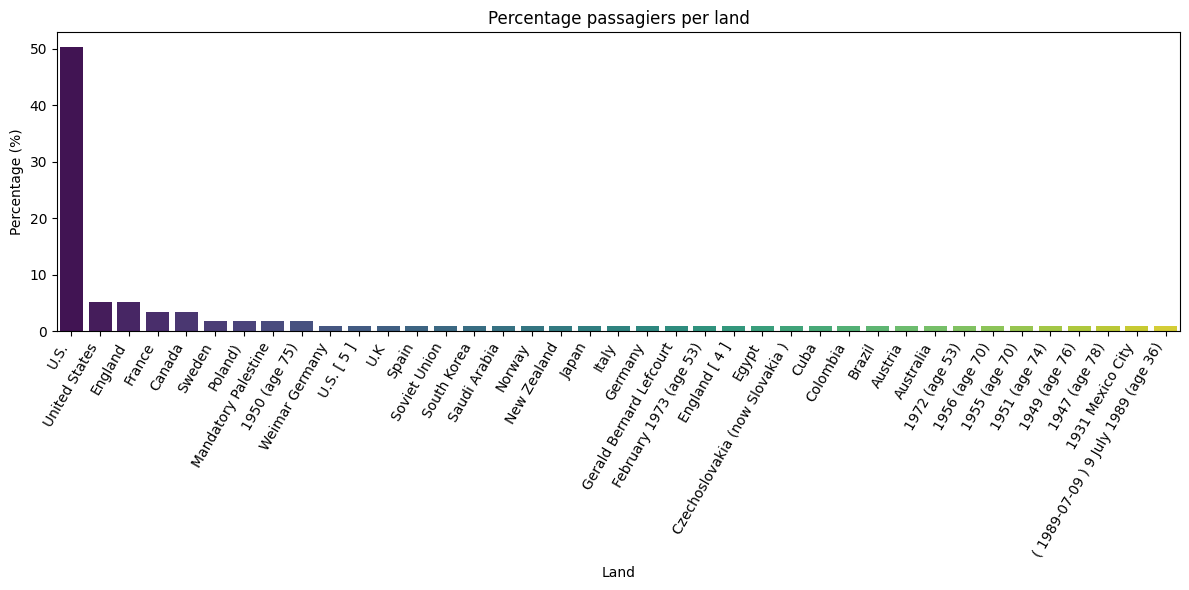

U.S.: 50.43%
United States: 5.13%
England: 5.13%
France: 3.42%
Canada: 3.42%
Sweden: 1.71%
Poland): 1.71%
Mandatory Palestine: 1.71%
1950 (age 75): 1.71%
Weimar Germany: 0.85%
U.S. [ 5 ]: 0.85%
U.K: 0.85%
Spain: 0.85%
Soviet Union: 0.85%
South Korea: 0.85%
Saudi Arabia: 0.85%
Norway: 0.85%
New Zealand: 0.85%
Japan: 0.85%
Italy: 0.85%
Germany: 0.85%
Gerald Bernard Lefcourt: 0.85%
February 1973 (age 53): 0.85%
England [ 4 ]: 0.85%
Egypt: 0.85%
Czechoslovakia (now Slovakia ): 0.85%
Cuba: 0.85%
Colombia: 0.85%
Brazil: 0.85%
Austria: 0.85%
Australia: 0.85%
1972 (age 53): 0.85%
1956 (age 70): 0.85%
1955 (age 70): 0.85%
1951 (age 74): 0.85%
1949 (age 76): 0.85%
1947 (age 78): 0.85%
1931 Mexico City: 0.85%
( 1989-07-09 ) 9 July 1989 (age 36): 0.85%


In [2]:
conn = sqlite3.connect('to_db/epstein.db')
cursor = conn.cursor()

# Haal aantallen per land op (negeer lege waarden)
rows = cursor.execute(
    """
    SELECT Country, COUNT(*) AS n
    FROM passengers
    WHERE Country IS NOT NULL AND TRIM(Country) != ''
    GROUP BY Country
    ORDER BY n DESC
    """
).fetchall()

conn.close()

countries = [row[0] for row in rows]
counts = [row[1] for row in rows]
total = sum(counts)
percentages = [(c / total) * 100 for c in counts]

plt.figure(figsize=(12, 6))
sns.barplot(x=countries, y=percentages, palette='viridis')

plt.title('Percentage passagiers per land')
plt.xlabel('Land')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Optioneel: tabel met percentages tonen
for country, pct in zip(countries, percentages):
    print(f"{country}: {pct:.2f}%")
